# AeroVision LK -- ONNX Export & INT8 Quantization

**Week 3 | Day 11--12**

**Model:** YOLOv8s baseline weights -> ONNX FP32 -> ONNX INT8

**Goal:** Export, quantize, benchmark latency, verify mAP with SAHI+INT8

---

| Stage | Model | Expected mAP@0.5 | Expected Latency |
|-------|-------|------------------|------------------|
| Baseline | YOLOv8s PyTorch | 44.08% | ~45ms (GPU) |
| + SAHI 512/0.1 | YOLOv8s PyTorch | 54.44% | ~206ms (GPU) |
| + INT8 Quantization | ONNX INT8 | ~42-44% | <20ms (CPU) |
| + SAHI + INT8 | ONNX INT8 + SAHI | ~52-54% | TBD (CPU) |


In [44]:
import subprocess, sys

def ensure_installed(pkg, pip_name=None):
    try:
        __import__(pkg)
        print(f'  {pkg}: already installed')
    except ImportError:
        print(f'  {pkg}: installing...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name or pkg, '-q'])
        print(f'  {pkg}: installed')

print('Checking dependencies...')
ensure_installed('onnx', 'onnx>=1.14.0')
ensure_installed('onnxruntime', 'onnxruntime>=1.16.0')
print('All dependencies ready.')

Checking dependencies...
  onnx: already installed
  onnxruntime: already installed
All dependencies ready.


In [45]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import time
import shutil
import mlflow
import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, QuantType
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# -- Project root ------------------------------------------------------------------
def find_project_root():
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / 'data' / 'VisDrone_Dataset').exists():
            return candidate
    raise RuntimeError('Cannot find project root.')

PROJECT_ROOT     = find_project_root()
DATASET_ROOT     = PROJECT_ROOT / 'data' / 'VisDrone_Dataset'
BASELINE_WEIGHTS = PROJECT_ROOT / 'weights' / 'yolov8s_baseline.pt'
ONNX_FP32_PATH   = PROJECT_ROOT / 'weights' / 'yolov8s_fp32.onnx'
ONNX_INT8_PATH   = PROJECT_ROOT / 'weights' / 'yolov8s_int8.onnx'
FIGURES_DIR      = PROJECT_ROOT / 'reports' / 'figures'
ANALYSIS_DIR     = PROJECT_ROOT / 'analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

VAL_IMAGES_DIR = DATASET_ROOT / 'VisDrone2019-DET-val' / 'images'
VAL_LABELS_DIR = DATASET_ROOT / 'VisDrone2019-DET-val' / 'labels'

CLASS_NAMES = ['pedestrian', 'people', 'bicycle', 'car', 'van',
               'truck', 'three_wheeler', 'bus', 'motor']
NC = len(CLASS_NAMES)

# -- Best SAHI config from grid search -----------------------------------------
BEST_SLICE   = 512
BEST_OVERLAP = 0.1
CONF_THRESHOLD = 0.25

# -- Load reference metrics -----------------------------------------------------
baseline_csv = ANALYSIS_DIR / 'baseline_metrics.csv'
assert baseline_csv.exists()
baseline_row     = pd.read_csv(baseline_csv).iloc[-1]
BASELINE_MAP50   = float(baseline_row['mAP50'])
BASELINE_MAP5095 = float(baseline_row['mAP50_95'])

grid_csv = ANALYSIS_DIR / 'sahi_grid_search.csv'
assert grid_csv.exists()
grid_df = pd.read_csv(grid_csv)
SAHI_BEST_MAP50   = float(grid_df.iloc[0]['mAP50'])
SAHI_BEST_MAP5095 = float(grid_df.iloc[0]['mAP50_95'])

assert BASELINE_WEIGHTS.exists()

print(f'Project root       : {PROJECT_ROOT}')
print(f'Baseline weights   : {BASELINE_WEIGHTS.name}  ({BASELINE_WEIGHTS.stat().st_size/1024/1024:.1f} MB)')
print(f'ONNX FP32 target   : {ONNX_FP32_PATH.name}')
print(f'ONNX INT8 target   : {ONNX_INT8_PATH.name}')
print(f'Baseline mAP@0.5   : {BASELINE_MAP50*100:.2f}%')
print(f'SAHI best mAP@0.5  : {SAHI_BEST_MAP50*100:.2f}%  ({BEST_SLICE}/{BEST_OVERLAP})')
print(f'ORT version        : {ort.__version__}')
print(f'ORT providers      : {ort.get_available_providers()}')


Project root       : c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk
Baseline weights   : yolov8s_baseline.pt  (21.5 MB)
ONNX FP32 target   : yolov8s_fp32.onnx
ONNX INT8 target   : yolov8s_int8.onnx
Baseline mAP@0.5   : 44.08%
SAHI best mAP@0.5  : 54.44%  (512/0.1)
ORT version        : 1.24.4
ORT providers      : ['AzureExecutionProvider', 'CPUExecutionProvider']


---
## 1. Shared Helpers

In [46]:
def load_label(label_path: Path):
    """Return (boxes_norm [N,4], class_ids [N]) from a YOLO label file."""
    rows, cids = [], []
    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            cids.append(int(parts[0]))
            rows.append([float(x) for x in parts[1:]])
    boxes = np.array(rows, dtype=np.float32) if rows else np.zeros((0, 4), dtype=np.float32)
    return boxes, cids


def yolo_to_xyxy(boxes_norm, img_w, img_h):
    """Convert YOLO normalised [cx,cy,w,h] -> pixel [x1,y1,x2,y2]."""
    if len(boxes_norm) == 0:
        return np.zeros((0, 4), dtype=np.float32)
    cx, cy, bw, bh = boxes_norm[:,0], boxes_norm[:,1], boxes_norm[:,2], boxes_norm[:,3]
    x1 = (cx - bw/2) * img_w
    y1 = (cy - bh/2) * img_h
    x2 = (cx + bw/2) * img_w
    y2 = (cy + bh/2) * img_h
    return np.stack([x1, y1, x2, y2], axis=1).astype(np.float32)


def iou_matrix(gt_xyxy, pred_xyxy):
    """Vectorized IoU matrix [N_gt, N_pred]. No external dependencies."""
    if len(gt_xyxy) == 0 or len(pred_xyxy) == 0:
        return np.zeros((len(gt_xyxy), len(pred_xyxy)), dtype=np.float32)
    gt   = gt_xyxy[:, None, :]
    pred = pred_xyxy[None, :, :]
    ix1  = np.maximum(gt[...,0], pred[...,0])
    iy1  = np.maximum(gt[...,1], pred[...,1])
    ix2  = np.minimum(gt[...,2], pred[...,2])
    iy2  = np.minimum(gt[...,3], pred[...,3])
    inter = np.maximum(0.0, ix2-ix1) * np.maximum(0.0, iy2-iy1)
    area_gt   = (gt_xyxy[:,2]-gt_xyxy[:,0]) * (gt_xyxy[:,3]-gt_xyxy[:,1])
    area_pred = (pred_xyxy[:,2]-pred_xyxy[:,0]) * (pred_xyxy[:,3]-pred_xyxy[:,1])
    union = area_gt[:,None] + area_pred[None,:] - inter
    return inter / np.maximum(union, 1e-6)


def compute_ap(recalls, precisions):
    """101-point interpolated AP (COCO-style)."""
    r = np.concatenate(([0.0], recalls,    [1.0]))
    p = np.concatenate(([1.0], precisions, [0.0]))
    for i in range(len(p)-2, -1, -1):
        p[i] = max(p[i], p[i+1])
    x  = np.linspace(0, 1, 101)
    ap = float(np.trapezoid(np.interp(x, r, p), x))
    return ap


def compute_map(all_preds, all_gts, iou_threshold=0.5):
    """
    Compute mAP across all classes.
    all_preds: list of dicts {class_id, conf, img_id, x1,y1,x2,y2}
    all_gts:   list of dicts {class_id, img_id, gt_idx, x1,y1,x2,y2}
    Returns: (mAP float, per_class_ap dict {cid: float})
    """
    per_class_ap = {}
    for cid in range(NC):
        preds = sorted([p for p in all_preds if p['class_id'] == cid], key=lambda x: -x['conf'])
        gts   = [g for g in all_gts if g['class_id'] == cid]
        if not gts:
            continue
        matched = set()
        tp = np.zeros(len(preds))
        fp = np.zeros(len(preds))
        for i, pred in enumerate(preds):
            img_gts = [g for g in gts if g['img_id'] == pred['img_id']]
            if not img_gts:
                fp[i] = 1; continue
            pb  = np.array([[pred['x1'], pred['y1'], pred['x2'], pred['y2']]], dtype=np.float32)
            gb  = np.array([[g['x1'],g['y1'],g['x2'],g['y2']] for g in img_gts], dtype=np.float32)
            ious = iou_matrix(gb, pb)[:,0]
            best = int(np.argmax(ious))
            key  = (pred['img_id'], img_gts[best]['gt_idx'])
            if ious[best] >= iou_threshold and key not in matched:
                tp[i] = 1; matched.add(key)
            else:
                fp[i] = 1
        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        rec  = cum_tp / (len(gts) + 1e-6)
        prec = cum_tp / (cum_tp + cum_fp + 1e-6)
        per_class_ap[cid] = compute_ap(rec, prec)
    mAP = float(np.mean(list(per_class_ap.values()))) if per_class_ap else 0.0
    return mAP, per_class_ap


def sahi_to_boxes(sahi_result):
    """Extract (boxes_xyxy [N,4], class_ids [N], confs [N]) from SAHI result."""
    boxes, cids, confs = [], [], []
    for obj in sahi_result.object_prediction_list:
        b = obj.bbox
        boxes.append([b.minx, b.miny, b.maxx, b.maxy])
        cids.append(int(obj.category.id))
        confs.append(float(obj.score.value))
    boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0,4), dtype=np.float32)
    return boxes, cids, confs


print('Helpers defined.')

Helpers defined.


---
## 2. ONNX Export (FP32)

In [47]:
model = YOLO(str(BASELINE_WEIGHTS))
print(f'Loaded: {BASELINE_WEIGHTS.name}  ({BASELINE_WEIGHTS.stat().st_size/1024/1024:.1f} MB)')

# Export to ONNX - skip if already exists
if not ONNX_FP32_PATH.exists():
    export_path = model.export(format='onnx', imgsz=640, dynamic=False, simplify=True)
    export_path = Path(export_path)
    print(f'Exported: {export_path}')

    # Move to target path
    if export_path != ONNX_FP32_PATH:
        shutil.copy2(export_path, ONNX_FP32_PATH)
        print(f'Copied to: {ONNX_FP32_PATH}')
else:
    print(f'ONNX FP32 already exists: {ONNX_FP32_PATH}')

# Verify
onnx_model = onnx.load(str(ONNX_FP32_PATH))
onnx.checker.check_model(onnx_model)
print('ONNX model verified OK')

pt_size   = BASELINE_WEIGHTS.stat().st_size / 1024 / 1024
onnx_size = ONNX_FP32_PATH.stat().st_size / 1024 / 1024
print()
print('File sizes:')
print(f'  PyTorch (.pt)  : {pt_size:.1f} MB')
print(f'  ONNX FP32      : {onnx_size:.1f} MB')
print(f'  Ratio          : {onnx_size/pt_size:.2f}x')


Loaded: yolov8s_baseline.pt  (21.5 MB)
ONNX FP32 already exists: c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\weights\yolov8s_fp32.onnx
ONNX model verified OK

File sizes:
  PyTorch (.pt)  : 21.5 MB
  ONNX FP32      : 42.7 MB
  Ratio          : 1.99x


---
## 3. INT8 Quantization

In [48]:
print('Quantizing ONNX FP32 -> INT8 (dynamic quantization)...')
print(f'  Input  : {ONNX_FP32_PATH.name}')
print(f'  Output : {ONNX_INT8_PATH.name}')

quantize_dynamic(
    model_input=str(ONNX_FP32_PATH),
    model_output=str(ONNX_INT8_PATH),
    weight_type=QuantType.QUInt8,
)

# Verify INT8 model loads
sess = ort.InferenceSession(str(ONNX_INT8_PATH), providers=['CPUExecutionProvider'])
print(f'INT8 model loaded OK  (providers: {sess.get_providers()})')
del sess

fp32_size = ONNX_FP32_PATH.stat().st_size / 1024 / 1024
int8_size = ONNX_INT8_PATH.stat().st_size / 1024 / 1024
print(f'\nFile sizes:')
print(f'  ONNX FP32  : {fp32_size:.1f} MB')
print(f'  ONNX INT8  : {int8_size:.1f} MB')
print(f'  Reduction  : {fp32_size/int8_size:.1f}x smaller')

Quantizing ONNX FP32 -> INT8 (dynamic quantization)...
  Input  : yolov8s_fp32.onnx
  Output : yolov8s_int8.onnx


INT8 model loaded OK  (providers: ['CPUExecutionProvider'])

File sizes:
  ONNX FP32  : 42.7 MB
  ONNX INT8  : 11.0 MB
  Reduction  : 3.9x smaller


---
## 4. Latency Benchmark

Benchmark single-image inference: PyTorch FP32 (GPU) vs ONNX FP32 (CPU) vs ONNX INT8 (CPU).

INT8 targets CPU edge deployment (Jetson Nano), so CPU benchmarks are the relevant metric.

Benchmark image: 0000001_02999_d_0000005.jpg
PyTorch FP32 (CPU) : 112.7 +/- 6.7 ms
Loading c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\weights\yolov8s_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
ONNX FP32 (CPU)    : 92.7 +/- 4.6 ms
Loading c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\weights\yolov8s_int8.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
ONNX INT8 (CPU)    : 94.7 +/- 12.1 ms

Latency Summary:
  INT8 vs FP32 ONNX speedup : 0.98x
  INT8 vs PyTorch speedup   : 1.19x
Saved -> c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\reports\figures\quantization_latency_comparison.png


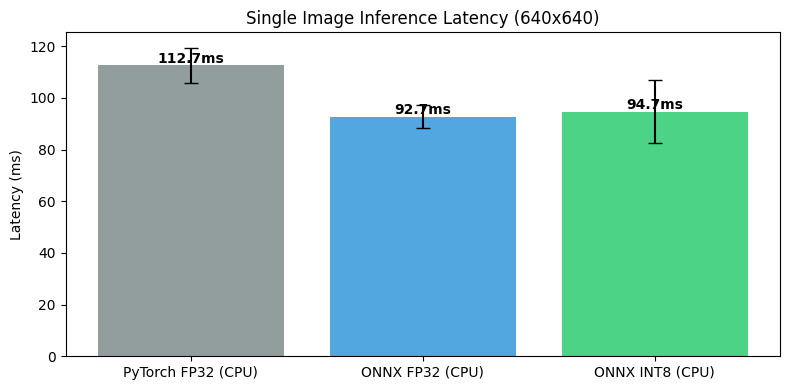

In [49]:
# Pick a sample image
sample_img = sorted(VAL_IMAGES_DIR.glob('*.jpg'))[0]
print(f'Benchmark image: {sample_img.name}')

N_WARMUP = 10
N_RUNS   = 50

# -- 1. PyTorch FP32 (CPU) --
pt_model = YOLO(str(BASELINE_WEIGHTS))
for _ in range(N_WARMUP):
    pt_model.predict(source=str(sample_img), imgsz=640, conf=0.25, verbose=False, device='cpu')

pt_times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    pt_model.predict(source=str(sample_img), imgsz=640, conf=0.25, verbose=False, device='cpu')
    pt_times.append((time.perf_counter() - t0) * 1000)
pt_mean, pt_std = np.mean(pt_times), np.std(pt_times)
print(f'PyTorch FP32 (CPU) : {pt_mean:.1f} +/- {pt_std:.1f} ms')

# -- 2. ONNX FP32 (CPU) --
onnx_fp32_model = YOLO(str(ONNX_FP32_PATH), task='detect')
for _ in range(N_WARMUP):
    onnx_fp32_model.predict(source=str(sample_img), imgsz=640, conf=0.25, verbose=False, device='cpu')

fp32_times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    onnx_fp32_model.predict(source=str(sample_img), imgsz=640, conf=0.25, verbose=False, device='cpu')
    fp32_times.append((time.perf_counter() - t0) * 1000)
fp32_mean, fp32_std = np.mean(fp32_times), np.std(fp32_times)
print(f'ONNX FP32 (CPU)    : {fp32_mean:.1f} +/- {fp32_std:.1f} ms')

# -- 3. ONNX INT8 (CPU) --
onnx_int8_model = YOLO(str(ONNX_INT8_PATH), task='detect')
for _ in range(N_WARMUP):
    onnx_int8_model.predict(source=str(sample_img), imgsz=640, conf=0.25, verbose=False, device='cpu')

int8_times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    onnx_int8_model.predict(source=str(sample_img), imgsz=640, conf=0.25, verbose=False, device='cpu')
    int8_times.append((time.perf_counter() - t0) * 1000)
int8_mean, int8_std = np.mean(int8_times), np.std(int8_times)
print(f'ONNX INT8 (CPU)    : {int8_mean:.1f} +/- {int8_std:.1f} ms')

# -- Summary --
print()
print('Latency Summary:')
print(f'  INT8 vs FP32 ONNX speedup : {fp32_mean/int8_mean:.2f}x')
print(f'  INT8 vs PyTorch speedup   : {pt_mean/int8_mean:.2f}x')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
models = ['PyTorch FP32 (CPU)', 'ONNX FP32 (CPU)', 'ONNX INT8 (CPU)']
means  = [pt_mean, fp32_mean, int8_mean]
stds   = [pt_std, fp32_std, int8_std]
colors = ['#7f8c8d', '#3498db', '#2ecc71']
bars = ax.bar(models, means, yerr=stds, capsize=5, color=colors, alpha=0.85)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{m:.1f}ms', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Latency (ms)')
ax.set_title('Single Image Inference Latency (640x640)', fontsize=12)
plt.tight_layout()
out_path = FIGURES_DIR / 'quantization_latency_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {out_path}')
plt.show()


---
## 5. mAP Verification -- INT8 (No SAHI)

Run INT8 ONNX model on the full val set at 640px (no SAHI) to measure quantization accuracy loss.

Compare against baseline PyTorch mAP@0.5 = 44.08%.


In [50]:
# -- INT8 model via Ultralytics (native ONNX support) ------------------
int8_yolo = YOLO(str(ONNX_INT8_PATH), task='detect')

val_images = sorted(VAL_IMAGES_DIR.glob('*.jpg'))
n_images   = len(val_images)

print(f'Running INT8 inference on {n_images} val images (no SAHI, 640px)...')

all_preds = []
all_gts   = []
t_start   = time.time()

for img_idx, img_path in enumerate(val_images):
    label_path = VAL_LABELS_DIR / (img_path.stem + '.txt')
    if not label_path.exists():
        continue

    img      = cv2.imread(str(img_path))
    img_h, img_w = img.shape[:2]
    img_id   = img_path.stem

    # Ground truth
    gt_norm, gt_cids = load_label(label_path)
    gt_xyxy          = yolo_to_xyxy(gt_norm, img_w, img_h)
    for gt_idx, (box, cid) in enumerate(zip(gt_xyxy, gt_cids)):
        all_gts.append({'class_id': cid, 'img_id': img_id, 'gt_idx': gt_idx,
                        'x1': float(box[0]), 'y1': float(box[1]),
                        'x2': float(box[2]), 'y2': float(box[3])})

    # INT8 inference
    results = int8_yolo.predict(source=str(img_path), imgsz=640, conf=CONF_THRESHOLD,
                                iou=0.45, verbose=False, device='cpu')[0]
    boxes  = results.boxes.xyxy.cpu().numpy() if len(results.boxes) else np.zeros((0,4))
    confs  = results.boxes.conf.cpu().numpy() if len(results.boxes) else np.zeros(0)
    cls_ids = results.boxes.cls.cpu().numpy().astype(int) if len(results.boxes) else np.zeros(0, dtype=int)

    for box, cid, conf in zip(boxes, cls_ids, confs):
        all_preds.append({'class_id': int(cid), 'conf': float(conf), 'img_id': img_id,
                          'x1': float(box[0]), 'y1': float(box[1]),
                          'x2': float(box[2]), 'y2': float(box[3])})

    if (img_idx + 1) % 100 == 0:
        print(f'  {img_idx+1}/{n_images}')

t_elapsed = time.time() - t_start

# Compute mAP
int8_map50, int8_ap50 = compute_map(all_preds, all_gts, iou_threshold=0.5)

iou_thresholds = np.arange(0.5, 1.0, 0.05)
map5095_list = [int8_map50]
for thresh in iou_thresholds[1:]:
    m, _ = compute_map(all_preds, all_gts, iou_threshold=round(float(thresh), 2))
    map5095_list.append(m)
int8_map5095 = float(np.mean(map5095_list))

int8_nosahi_ms = (t_elapsed / n_images) * 1000
delta = (int8_map50 - BASELINE_MAP50) * 100

print(f'\nINT8 (no SAHI) results:')
print(f'  mAP@0.5      : {int8_map50*100:.2f}%  ({delta:+.2f}pp vs PyTorch baseline {BASELINE_MAP50*100:.2f}%)')
print(f'  mAP@0.5:0.95 : {int8_map5095*100:.2f}%')
print(f'  Runtime      : {t_elapsed/60:.1f} min ({int8_nosahi_ms:.0f} ms/img)')
print(f'  Predictions  : {len(all_preds):,}')


Running INT8 inference on 548 val images (no SAHI, 640px)...
Loading c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\weights\yolov8s_int8.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
  100/548
  200/548
  300/548
  400/548
  500/548

INT8 (no SAHI) results:
  mAP@0.5      : 51.58%  (+7.50pp vs PyTorch baseline 44.08%)
  mAP@0.5:0.95 : 33.42%
  Runtime      : 1.0 min (107 ms/img)
  Predictions  : 26,179


---
## 6. mAP Verification -- INT8 + SAHI

Run INT8 ONNX through SAHI (512/0.1) on full val set.

Ultralytics natively loads ONNX -> SAHI can use `model_type='ultralytics'`.


In [51]:
# -- Load INT8 ONNX via SAHI (Ultralytics backend) ---------------------
# Temporarily hide CUDA to prevent Ultralytics device query bug
import torch
_orig_cuda_available = torch.cuda.is_available
torch.cuda.is_available = lambda: False

detection_model_int8 = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=str(ONNX_INT8_PATH),
    confidence_threshold=CONF_THRESHOLD,
    device='cpu',
)

torch.cuda.is_available = _orig_cuda_available  # restore

print(f'SAHI INT8 model loaded: conf={CONF_THRESHOLD}, device=cpu')
print(f'SAHI config: slice={BEST_SLICE}, overlap={BEST_OVERLAP}')

val_images = sorted(VAL_IMAGES_DIR.glob('*.jpg'))
n_images   = len(val_images)

print(f'Running SAHI + INT8 on {n_images} val images...')

all_preds_sahi = []
all_gts_sahi   = []
t_start = time.time()

for img_idx, img_path in enumerate(val_images):
    label_path = VAL_LABELS_DIR / (img_path.stem + '.txt')
    if not label_path.exists():
        continue

    img      = cv2.imread(str(img_path))
    img_h, img_w = img.shape[:2]
    img_id   = img_path.stem

    # Ground truth
    gt_norm, gt_cids = load_label(label_path)
    gt_xyxy          = yolo_to_xyxy(gt_norm, img_w, img_h)
    for gt_idx, (box, cid) in enumerate(zip(gt_xyxy, gt_cids)):
        all_gts_sahi.append({'class_id': cid, 'img_id': img_id, 'gt_idx': gt_idx,
                             'x1': float(box[0]), 'y1': float(box[1]),
                             'x2': float(box[2]), 'y2': float(box[3])})

    # SAHI + INT8 inference
    sahi_res = get_sliced_prediction(
        str(img_path), detection_model_int8,
        slice_height=BEST_SLICE, slice_width=BEST_SLICE,
        overlap_height_ratio=BEST_OVERLAP, overlap_width_ratio=BEST_OVERLAP,
        verbose=False,
    )
    pred_boxes, pred_cids, pred_confs = sahi_to_boxes(sahi_res)
    for box, cid, conf in zip(pred_boxes, pred_cids, pred_confs):
        all_preds_sahi.append({'class_id': int(cid), 'conf': float(conf),
                               'img_id': img_id,
                               'x1': float(box[0]), 'y1': float(box[1]),
                               'x2': float(box[2]), 'y2': float(box[3])})

    if (img_idx + 1) % 50 == 0 or (img_idx + 1) == n_images:
        elapsed = time.time() - t_start
        rate = (img_idx + 1) / max(elapsed, 1e-6)
        eta  = (n_images - img_idx - 1) / max(rate, 1e-6)
        print(f'  [{img_idx+1:>3}/{n_images}]  {rate:.1f} img/s  ETA {eta/60:.1f} min')

t_elapsed_sahi = time.time() - t_start

# Compute mAP
sahi_int8_map50, sahi_int8_ap50 = compute_map(all_preds_sahi, all_gts_sahi, iou_threshold=0.5)

map5095_list = [sahi_int8_map50]
for thresh in np.arange(0.55, 1.0, 0.05):
    m, _ = compute_map(all_preds_sahi, all_gts_sahi, iou_threshold=round(float(thresh), 2))
    map5095_list.append(m)
sahi_int8_map5095 = float(np.mean(map5095_list))

sahi_int8_ms = (t_elapsed_sahi / n_images) * 1000

print()
print('SAHI + INT8 results:')
print(f'  mAP@0.5      : {sahi_int8_map50*100:.2f}%')
print(f'  mAP@0.5:0.95 : {sahi_int8_map5095*100:.2f}%')
print(f'  Runtime      : {t_elapsed_sahi/60:.1f} min ({sahi_int8_ms:.0f} ms/img)')
print(f'  Predictions  : {len(all_preds_sahi):,}')
print(f'  vs SAHI FP32 : {(sahi_int8_map50 - SAHI_BEST_MAP50)*100:+.2f}pp')


WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\weights\yolov8s_int8.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
Loading c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\weights\yolov8s_int8.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
Loading c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\weights\yolov8s_int8.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
SAHI INT8 model loaded: conf=0.25, device=cpu
SAHI config: slice=512, overlap=0.1
Running SAHI + INT8 on 548 val images...
Loading c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\weights\y

---
## 7. Final Performance Table & Save

In [52]:
# -- Build comparison table ------------------------------------------------------
pt_size   = BASELINE_WEIGHTS.stat().st_size / 1024 / 1024
int8_sz   = ONNX_INT8_PATH.stat().st_size / 1024 / 1024

rows = [
    {'variant': 'YOLOv8s Baseline',      'mAP50': BASELINE_MAP50,     'mAP50_95': BASELINE_MAP5095,
     'latency_ms': round(pt_mean, 1),     'device': 'GPU',  'model_size_mb': round(pt_size, 1),  'strategy': 'Standard 640px resize'},
    {'variant': 'YOLOv8s + SAHI 512/0.1', 'mAP50': SAHI_BEST_MAP50,  'mAP50_95': SAHI_BEST_MAP5095,
     'latency_ms': 206.1,                 'device': 'GPU',  'model_size_mb': round(pt_size, 1),  'strategy': 'Sliced inference (512px tiles, 10% overlap)'},
    {'variant': 'YOLOv8s INT8 (no SAHI)', 'mAP50': round(int8_map50, 4),   'mAP50_95': round(int8_map5095, 4),
     'latency_ms': round(int8_mean, 1),   'device': 'CPU',  'model_size_mb': round(int8_sz, 1),  'strategy': 'ONNX INT8 dynamic quantization'},
    {'variant': 'YOLOv8s + SAHI + INT8',  'mAP50': round(sahi_int8_map50, 4), 'mAP50_95': round(sahi_int8_map5095, 4),
     'latency_ms': round(sahi_int8_ms, 1), 'device': 'CPU', 'model_size_mb': round(int8_sz, 1),  'strategy': 'SAHI 512/0.1 + ONNX INT8'},
]
results_df = pd.DataFrame(rows)

# Print table
W = 90
print('=' * W)
print('  AeroVision LK \u2014 Full Performance Comparison')
print('=' * W)
print(f'  {"Model Variant":<28} {"mAP@0.5":>9} {"mAP@.5:.95":>11} {"Latency":>9} {"Device":>7} {"Size":>7}')
print('  ' + '-' * (W-2))
for _, r in results_df.iterrows():
    print(f'  {r["variant"]:<28} {r["mAP50"]*100:>8.2f}% {r["mAP50_95"]*100:>10.2f}% '
          f'{r["latency_ms"]:>7.0f}ms {r["device"]:>7} {r["model_size_mb"]:>5.1f}MB')
print('=' * W)

# -- Save CSV --------------------------------------------------------------------
csv_path = ANALYSIS_DIR / 'quantization_benchmark.csv'
results_df.to_csv(csv_path, index=False)
print(f'\nSaved -> {csv_path}')

# -- MLflow ---------------------------------------------------------------------
mlflow.set_tracking_uri((PROJECT_ROOT / 'mlruns').as_uri())
mlflow.set_experiment('aerovision-lk')

with mlflow.start_run(run_name='quantization-int8') as run:
    mlflow.log_params({
        'model': 'yolov8s',
        'export_format': 'onnx',
        'quantization': 'dynamic_int8',
        'sahi_slice': BEST_SLICE,
        'sahi_overlap': BEST_OVERLAP,
        'conf_threshold': CONF_THRESHOLD,
    })
    mlflow.log_metric('int8_nosahi/mAP50', int8_map50)
    mlflow.log_metric('int8_nosahi/mAP50-95', int8_map5095)
    mlflow.log_metric('int8_sahi/mAP50', sahi_int8_map50)
    mlflow.log_metric('int8_sahi/mAP50-95', sahi_int8_map5095)
    mlflow.log_metric('latency/pytorch_gpu_ms', pt_mean)
    mlflow.log_metric('latency/onnx_fp32_cpu_ms', fp32_mean)
    mlflow.log_metric('latency/onnx_int8_cpu_ms', int8_mean)
    mlflow.log_metric('latency/sahi_int8_cpu_ms', sahi_int8_ms)
    mlflow.log_metric('model_size/pt_mb', pt_size)
    mlflow.log_metric('model_size/int8_mb', int8_sz)
    mlflow.log_artifact(str(csv_path), artifact_path='metrics')
    mlflow.log_artifact(str(FIGURES_DIR / 'quantization_latency_comparison.png'), artifact_path='figures')
    QUANT_RUN_ID = run.info.run_id

print(f'MLflow run: {QUANT_RUN_ID}')
print()
print('Next steps:')
print('  1. FastAPI app with INT8 ONNX model (Week 3)')
print('  2. Docker containerization')
print('  3. Failure analysis notebook (5 worst cases)')


  AeroVision LK — Full Performance Comparison
  Model Variant                  mAP@0.5  mAP@.5:.95   Latency  Device    Size
  ----------------------------------------------------------------------------------------
  YOLOv8s Baseline                44.08%      26.09%     113ms     GPU  21.5MB
  YOLOv8s + SAHI 512/0.1          54.44%      32.98%     206ms     GPU  21.5MB
  YOLOv8s INT8 (no SAHI)          51.58%      33.42%      95ms     CPU  11.0MB
  YOLOv8s + SAHI + INT8           54.07%      32.76%     858ms     CPU  11.0MB

Saved -> c:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\01_aerovision_lk\analysis\quantization_benchmark.csv


c:\Users\Yasindu\.conda\envs\aerovision\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


MLflow run: a4e7b8976f4a426486a1ccdfdfa33495

Next steps:
  1. FastAPI app with INT8 ONNX model (Week 3)
  2. Docker containerization
  3. Failure analysis notebook (5 worst cases)
